In [1]:
import requests
import pandas as pd
from datetime import datetime

# Coins added: BTC, ETH, SOL, LTC, XRP, DOT
coins = "bitcoin,ethereum,solana,litecoin,ripple,polkadot"

url = f"https://api.coingecko.com/api/v3/coins/markets?vs_currency=usd&ids={coins}"

data = requests.get(url).json()

rows = []

for coin in data:
    change = coin["price_change_percentage_24h"]

    # Task 2: Formatting with arrows
    if change > 0:
        change_fmt = f"📈 {change:.2f}%"
    else:
        change_fmt = f"📉 {change:.2f}%"

    rows.append([
        coin["name"],
        coin["current_price"],
        change_fmt,
        coin["total_volume"]
    ])

df = pd.DataFrame(rows, columns=["Crypto", "Price (USD)", "24h Change", "Volume"])
df

,Crypto,Price (USD),24h Change,Volume
0,Bitcoin,86884.00,📈 1.17%,78450335652
1,Ethereum,2800.50,📉 -0.77%,30133734111
2,XRP,2.01,📉 -0.83%,4290285796
3,Solana,126.71,📈 0.30%,5590810784
4,Litecoin,77.47,📈 0.02%,673053814
5,Polkadot,2.05,📈 1.39%,190853149


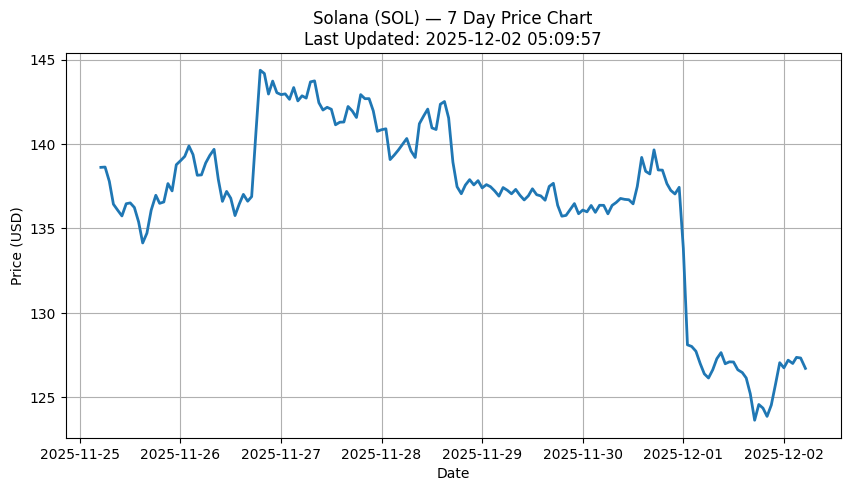

In [2]:
import matplotlib.pyplot as plt

sol_url = "https://api.coingecko.com/api/v3/coins/solana/market_chart?vs_currency=usd&days=7"
sol_data = requests.get(sol_url).json()

prices = sol_data["prices"]

# Extract time & price
times = [datetime.fromtimestamp(t[0]/1000) for t in prices]
values = [p[1] for p in prices]

# Task 4: Add last updated time
last_updated = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

plt.figure(figsize=(10,5))
plt.plot(times, values, linewidth=2)
plt.title(f"Solana (SOL) — 7 Day Price Chart\nLast Updated: {last_updated}")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()
